# Pengembangan *physics informed neural networks* (PINNs) untuk penyelesaian PDP

# 1. Import *Library* dan *Package* yang diperlukan.

Kode dapat dijalankan dengan TensorFlow versi `2.5.x`.
Implementasi model dilakukan dengan *library* [NumPy](https://numpy.org/doc/stable/user/whatisnumpy.html) dan *library* untuk *machine learning* [TensorFlow](https://www.tensorflow.org/).

Telah dikembangkan implementasi *class* untuk pembuatan PINN sebagai objek dari Keras pada sebuah *package* yang disimpan dalam *file* `PINNPDESolver.py`.

Komputasi dilakukan pada Google Colab.

In [1]:
print_plot = True

from google.colab import drive
drive.mount('/content/drive')
# Current Working Directory
dir = '/content/drive/My Drive/Tugas Akhir/Colab'

import sys
sys.path.insert(0, dir)

# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np

# Import Physics-Informed Neural Network
import PINNPDESolver as pinn

# Import Combined Learning Rate Decay
from CombinedDecay import CombinedDecay

# Import time
from time import time

# Import matplotlib for plots
import matplotlib.pyplot as plt

# Creating tables
import pandas as pd
from tabulate import tabulate

Mounted at /content/drive


In [2]:
if print_plot is True:
  !sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended

  pgf_with_latex = {                      # setup matplotlib to use latex for output
      "pgf.texsystem": "pdflatex",        # change this if using xetex or lautex
      "text.usetex": True,                # use LaTeX to write all text
      "font.family": "serif",
      "font.serif": [],                   # blank entries should cause plots to inherit fonts from the document
      "font.sans-serif": [],
      "font.monospace": [],
      "axes.labelsize": 24,               # LaTeX default is 10pt font.
      "font.size": 24,
      "legend.fontsize": 24,               # Make the legend/label fonts a little smaller
      "xtick.labelsize": 22,
      "ytick.labelsize": 22,
      # "pgf.preamble": [
      #     r"\usepackage[utf8x]{inputenc}",    # use utf8 fonts becasue your computer can handle it :)
      #     r"\usepackage[T1]{fontenc}",        # plots will be generated using this preamble
      #     ]
      }
  plt.rcParams.update(pgf_with_latex)

Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern
  fonts-noto-mono fonts-texgyre fonts-urw-base35 ghostscript javascript-common
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libgs9 libgs9-common libidn11 libijs-0.35 libjbig2dec0
  libjs-jquery libkpathsea6 libpdfbox-java libptexenc1 libruby2.7 libsynctex2
  libteckit0 libtexlua53 libtexluajit2 libzzip-0-13 lmodern pfb2t1c2pfb
  poppler-data preview-latex-style rake ruby ruby-minitest ruby-net-telnet
  ruby-power-assert ruby-test-unit ruby-xmlrpc ruby2.7 rubygems-integration
  t1utils tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-pictures
  texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf g

In [3]:
# Set data type
DTYPE='float32'
# for i in range(1,60+1):
#   print("n=",i, "\t", 2**i)
# for i in range(1,60+1):
#   print("n=",i, "\t", 2**tf.constant([i], dtype='int64'))

# DTYPE='float64'
tf.keras.backend.set_floatx(DTYPE)

# Set constants
pi = tf.constant(np.pi, dtype=DTYPE)

# 2. Persamaan Korteweg-de Vries (KdV) 3-Soliton dan Transformasi menjadi *Loss Function*

Persamaan KdV yang akan digunakan adalah

$$
\begin{equation}
    u_t + 6uu_{x} + u_{xxx} = 0, \quad -\infty<x<\infty, \quad t>0
\end{equation}.
$$
Diberikan *initial condition* (IC)
$$
\begin{equation}
    u(x,\,0) = -N(N+1)sech^2(x).
\end{equation}
$$
<!-- Solusi unik masalah ini adalah
$$
\begin{equation}
	        u(x,\;t) = -2sech^2(x-4t).
\end{equation}
$$ -->

In [4]:
a = [1, 0.7, 0.4]
lambda_star = [6, 1]

# Define initial condition
import math
def fun_u_0(x):
    return 4 * a[0] ** 2 * (2 * (a[1] ** 2 + a[2] ** 2) * (a[1] + a[2]) ** 2 * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp(2 * x * (a[1] + a[2])) + (a[1] - a[2]) ** 4 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(4 * x * (a[1] + a[2])) / 2 + (a[1] + a[2]) ** 2 * ((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp((2 * a[1] + 4 * a[2]) * x) + (a[1] - a[2]) ** 2 * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] - a[1]) ** 2 * tf.exp((4 * a[1] + 2 * a[2]) * x) + (2 * (a[0] + a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp(2 * x * a[1]) + 2 * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] + a[1]) ** 2 * tf.exp(2 * x * a[2]) + (a[0] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(4 * x * a[1]) + ((a[0] - a[2]) ** 2 * tf.exp(4 * x * a[2]) + (a[0] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[1] + a[2]) ** 2 / 2)) / tf.cosh(x * a[0] + tf.math.log(((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * (a[1] + a[2])) + ((a[0] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * a[1]) + ((a[0] - a[2]) ** 2 * tf.exp(2 * x * a[2]) + (a[0] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[1] + a[2]) ** 2) / ((a[1] - a[2]) ** 2 * tf.exp(2 * x * (a[1] + a[2])) + (a[1] + a[2]) ** 2 * (tf.exp(2 * x * a[1]) + tf.exp(2 * x * a[2]) + 1)) / (a[0] + a[1]) ** 2 / (a[0] + a[2]) ** 2) / 2) ** 2 / ((a[1] - a[2]) ** 2 * tf.exp(2 * x * (a[1] + a[2])) + (a[1] + a[2]) ** 2 * (tf.exp(2 * x * a[1]) + tf.exp(2 * x * a[2]) + 1)) / ((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * (a[1] + a[2])) + ((a[0] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * a[1]) + ((a[0] - a[2]) ** 2 * tf.exp(2 * x * a[2]) + (a[0] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[1] + a[2]) ** 2) + 4 * (-2 * (a[1] - a[2]) * (a[1] + a[2]) * (a[0] ** 2 + a[2] ** 2) * (a[0] + a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp(2 * x * (a[0] + a[2])) + (a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 4 * (a[0] - a[1]) ** 2 * tf.exp(4 * x * (a[0] + a[2])) / 2 + (a[0] + a[2]) ** 2 * (-(a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp((2 * a[0] + 4 * a[2]) * x) + (a[1] - a[2]) * (a[1] + a[2]) * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp((4 * a[0] + 2 * a[2]) * x) + (-2 * (a[1] + a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp(2 * x * a[0]) + 2 * (a[1] - a[2]) * (a[1] + a[2]) * (a[0] + a[1]) ** 2 * tf.exp(2 * x * a[2]) + (a[1] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(4 * x * a[0]) + (a[0] + a[1]) ** 2 * ((a[1] - a[2]) ** 2 * tf.exp(4 * x * a[2]) + (a[1] + a[2]) ** 2)) * (a[0] + a[2]) ** 2 / 2)) * a[1] ** 2 / ((a[0] - a[2]) ** 2 * tf.exp(2 * x * (a[0] + a[2])) + (a[0] + a[2]) ** 2 * (tf.exp(2 * x * a[0]) + tf.exp(2 * x * a[2]) + 1)) / tf.cosh(x * a[1] + tf.math.log(((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * (a[0] + a[2])) + ((a[1] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * a[0]) + ((a[1] - a[2]) ** 2 * tf.exp(2 * x * a[2]) + (a[1] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[0] + a[2]) ** 2) / ((a[0] - a[2]) ** 2 * tf.exp(2 * x * (a[0] + a[2])) + (a[0] + a[2]) ** 2 * (tf.exp(2 * x * a[0]) + tf.exp(2 * x * a[2]) + 1)) / (a[0] + a[1]) ** 2 / (a[1] + a[2]) ** 2) / 2) ** 2 / ((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * (a[0] + a[2])) + ((a[1] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * a[0]) + ((a[1] - a[2]) ** 2 * tf.exp(2 * x * a[2]) + (a[1] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[0] + a[2]) ** 2) - 4 * (-2 * (a[1] - a[2]) * (a[1] + a[2]) * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] ** 2 + a[1] ** 2) * (a[0] + a[1]) ** 2 * tf.exp(2 * x * (a[0] + a[1])) - (a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 4 * tf.exp(4 * x * (a[0] + a[1])) / 2 + (a[0] + a[1]) ** 2 * ((a[1] - a[2]) ** 2 * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] - a[1]) ** 2 * tf.exp((2 * a[0] + 4 * a[1]) * x) + (a[1] - a[2]) * (a[1] + a[2]) * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp((4 * a[0] + 2 * a[1]) * x) - (a[0] + a[1]) ** 2 * (-2 * (a[1] + a[2]) ** 2 * (a[0] - a[2]) * (a[0] + a[2]) * tf.exp(2 * x * a[0]) - 2 * (a[1] - a[2]) * (a[1] + a[2]) * (a[0] + a[2]) ** 2 * tf.exp(2 * x * a[1]) + (a[1] + a[2]) ** 2 * (a[0] - a[2]) ** 2 * tf.exp(4 * x * a[0]) + (a[0] + a[2]) ** 2 * ((a[1] - a[2]) ** 2 * tf.exp(4 * x * a[1]) + (a[1] + a[2]) ** 2)) / 2)) * a[2] ** 2 / tf.cosh(x * a[2] + tf.math.log(((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * (a[0] + a[1])) + (a[0] + a[1]) ** 2 * ((a[1] + a[2]) ** 2 * (a[0] - a[2]) ** 2 * tf.exp(2 * x * a[0]) + ((a[1] - a[2]) ** 2 * tf.exp(2 * x * a[1]) + (a[1] + a[2]) ** 2) * (a[0] + a[2]) ** 2)) / ((a[0] - a[1]) ** 2 * tf.exp(2 * x * (a[0] + a[1])) + (a[0] + a[1]) ** 2 * (tf.exp(2 * x * a[0]) + tf.exp(2 * x * a[1]) + 1)) / (a[0] + a[2]) ** 2 / (a[1] + a[2]) ** 2) / 2) ** 2 / ((a[0] - a[1]) ** 2 * tf.exp(2 * x * (a[0] + a[1])) + (a[0] + a[1]) ** 2 * (tf.exp(2 * x * a[0]) + tf.exp(2 * x * a[1]) + 1)) / ((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(2 * x * (a[0] + a[1])) + (a[0] + a[1]) ** 2 * ((a[1] + a[2]) ** 2 * (a[0] - a[2]) ** 2 * tf.exp(2 * x * a[0]) + ((a[1] - a[2]) ** 2 * tf.exp(2 * x * a[1]) + (a[1] + a[2]) ** 2) * (a[0] + a[2]) ** 2))
    # N = 3
    # return - N*(N+1)*(1/tf.math.cosh(x))**2 

# Define residual of the PDE
def fun_r(t, x, u, u_t, u_x, u_xx, u_xxx, lambd = lambda_star):
    return u_t + lambd[0] * u * u_x + lambd[1] * u_xxx

In [5]:
# Solusi Eksplisit
def u_expl(t, x):
    """Solusi eksplisit persamaan KdV."""
    return 4 * a[0] ** 2 * (2 * (a[1] ** 2 + a[2] ** 2) * (a[1] + a[2]) ** 2 * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp(-8 * (t * a[1] ** 2 - t * a[1] * a[2] + t * a[2] ** 2 - x / 4) * (a[1] + a[2])) + (a[1] - a[2]) ** 4 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-16 * (t * a[1] ** 2 - t * a[1] * a[2] + t * a[2] ** 2 - x / 4) * (a[1] + a[2])) / 2 + (a[1] + a[2]) ** 2 * ((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp((2 * a[1] + 4 * a[2]) * x - 8 * (a[1] ** 3 + 2 * a[2] ** 3) * t) + (a[1] - a[2]) ** 2 * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] - a[1]) ** 2 * tf.exp((4 * a[1] + 2 * a[2]) * x - 16 * t * a[1] ** 3 - 8 * t * a[2] ** 3) + (2 * (a[0] + a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 2 * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] + a[1]) ** 2 * tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + (a[0] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-16 * t * a[1] ** 3 + 4 * x * a[1]) + ((a[0] - a[2]) ** 2 * tf.exp(-16 * t * a[2] ** 3 + 4 * x * a[2]) + (a[0] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[1] + a[2]) ** 2 / 2)) / tf.math.cosh(4 * t * a[0] ** 3 - x * a[0] - tf.math.log(((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * (t * a[1] ** 2 - t * a[1] * a[2] + t * a[2] ** 2 - x / 4) * (a[1] + a[2])) + ((a[0] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + ((a[0] - a[2]) ** 2 * tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + (a[0] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[1] + a[2]) ** 2) / ((a[1] - a[2]) ** 2 * tf.exp(-8 * (t * a[1] ** 2 - t * a[1] * a[2] + t * a[2] ** 2 - x / 4) * (a[1] + a[2])) + (a[1] + a[2]) ** 2 * (tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + 1)) / (a[0] + a[1]) ** 2 / (a[0] + a[2]) ** 2) / 2) ** 2 / ((a[1] - a[2]) ** 2 * tf.exp(-8 * (t * a[1] ** 2 - t * a[1] * a[2] + t * a[2] ** 2 - x / 4) * (a[1] + a[2])) + (a[1] + a[2]) ** 2 * (tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + 1)) / ((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * (t * a[1] ** 2 - t * a[1] * a[2] + t * a[2] ** 2 - x / 4) * (a[1] + a[2])) + ((a[0] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + ((a[0] - a[2]) ** 2 * tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + (a[0] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[1] + a[2]) ** 2) + 4 * (-2 * (a[1] - a[2]) * (a[1] + a[2]) * (a[0] ** 2 + a[2] ** 2) * (a[0] + a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[2] + t * a[2] ** 2 - x / 4) * (a[0] + a[2])) + (a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 4 * (a[0] - a[1]) ** 2 * tf.exp(-16 * (t * a[0] ** 2 - t * a[0] * a[2] + t * a[2] ** 2 - x / 4) * (a[0] + a[2])) / 2 + (a[0] + a[2]) ** 2 * (-(a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp((2 * a[0] + 4 * a[2]) * x - 8 * (a[0] ** 3 + 2 * a[2] ** 3) * t) + (a[1] - a[2]) * (a[1] + a[2]) * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp((4 * a[0] + 2 * a[2]) * x - 16 * t * a[0] ** 3 - 8 * t * a[2] ** 3) + (-2 * (a[1] + a[2]) ** 2 * (a[0] - a[1]) * (a[0] + a[1]) * tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + 2 * (a[1] - a[2]) * (a[1] + a[2]) * (a[0] + a[1]) ** 2 * tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + (a[1] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-16 * t * a[0] ** 3 + 4 * x * a[0]) + (a[0] + a[1]) ** 2 * ((a[1] - a[2]) ** 2 * tf.exp(-16 * t * a[2] ** 3 + 4 * x * a[2]) + (a[1] + a[2]) ** 2)) * (a[0] + a[2]) ** 2 / 2)) * a[1] ** 2 / ((a[0] - a[2]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[2] + t * a[2] ** 2 - x / 4) * (a[0] + a[2])) + (a[0] + a[2]) ** 2 * (tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + 1)) / tf.math.cosh(4 * t * a[1] ** 3 - x * a[1] - tf.math.log(((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[2] + t * a[2] ** 2 - x / 4) * (a[0] + a[2])) + ((a[1] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + ((a[1] - a[2]) ** 2 * tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + (a[1] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[0] + a[2]) ** 2) / ((a[0] - a[2]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[2] + t * a[2] ** 2 - x / 4) * (a[0] + a[2])) + (a[0] + a[2]) ** 2 * (tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + 1)) / (a[0] + a[1]) ** 2 / (a[1] + a[2]) ** 2) / 2) ** 2 / ((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[2] + t * a[2] ** 2 - x / 4) * (a[0] + a[2])) + ((a[1] + a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + ((a[1] - a[2]) ** 2 * tf.exp(-8 * t * a[2] ** 3 + 2 * x * a[2]) + (a[1] + a[2]) ** 2) * (a[0] + a[1]) ** 2) * (a[0] + a[2]) ** 2) - 4 * (-2 * (a[1] - a[2]) * (a[1] + a[2]) * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] ** 2 + a[1] ** 2) * (a[0] + a[1]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[1] + t * a[1] ** 2 - x / 4) * (a[0] + a[1])) - (a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 4 * tf.exp(-16 * (t * a[0] ** 2 - t * a[0] * a[1] + t * a[1] ** 2 - x / 4) * (a[0] + a[1])) / 2 + (a[0] + a[1]) ** 2 * ((a[1] - a[2]) ** 2 * (a[0] - a[2]) * (a[0] + a[2]) * (a[0] - a[1]) ** 2 * tf.exp((2 * a[0] + 4 * a[1]) * x - 8 * (a[0] ** 3 + 2 * a[1] ** 3) * t) + (a[1] - a[2]) * (a[1] + a[2]) * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp((4 * a[0] + 2 * a[1]) * x - 16 * t * a[0] ** 3 - 8 * t * a[1] ** 3) - (a[0] + a[1]) ** 2 * (-2 * (a[1] + a[2]) ** 2 * (a[0] - a[2]) * (a[0] + a[2]) * tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) - 2 * (a[1] - a[2]) * (a[1] + a[2]) * (a[0] + a[2]) ** 2 * tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + (a[1] + a[2]) ** 2 * (a[0] - a[2]) ** 2 * tf.exp(-16 * t * a[0] ** 3 + 4 * x * a[0]) + (a[0] + a[2]) ** 2 * ((a[1] - a[2]) ** 2 * tf.exp(-16 * t * a[1] ** 3 + 4 * x * a[1]) + (a[1] + a[2]) ** 2)) / 2)) * a[2] ** 2 / tf.math.cosh(4 * t * a[2] ** 3 - x * a[2] - tf.math.log(((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[1] + t * a[1] ** 2 - x / 4) * (a[0] + a[1])) + (a[0] + a[1]) ** 2 * ((a[1] + a[2]) ** 2 * (a[0] - a[2]) ** 2 * tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + ((a[1] - a[2]) ** 2 * tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + (a[1] + a[2]) ** 2) * (a[0] + a[2]) ** 2)) / ((a[0] - a[1]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[1] + t * a[1] ** 2 - x / 4) * (a[0] + a[1])) + (a[0] + a[1]) ** 2 * (tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 1)) / (a[0] + a[2]) ** 2 / (a[1] + a[2]) ** 2) / 2) ** 2 / ((a[0] - a[1]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[1] + t * a[1] ** 2 - x / 4) * (a[0] + a[1])) + (a[0] + a[1]) ** 2 * (tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + 1)) / ((a[1] - a[2]) ** 2 * (a[0] - a[2]) ** 2 * (a[0] - a[1]) ** 2 * tf.exp(-8 * (t * a[0] ** 2 - t * a[0] * a[1] + t * a[1] ** 2 - x / 4) * (a[0] + a[1])) + (a[0] + a[1]) ** 2 * ((a[1] + a[2]) ** 2 * (a[0] - a[2]) ** 2 * tf.exp(-8 * t * a[0] ** 3 + 2 * x * a[0]) + ((a[1] - a[2]) ** 2 * tf.exp(-8 * t * a[1] ** 3 + 2 * x * a[1]) + (a[1] + a[2]) ** 2) * (a[0] + a[2]) ** 2))

In [6]:
# Set boundary
tmin = -3.
tmax = 3.
xmin = -10.
xmax = 10.
# xmin = -20.
# xmax = 20.

# Lower bounds
lb = tf.constant([tmin, xmin], dtype=DTYPE)
# Upper bounds
ub = tf.constant([tmax, xmax], dtype=DTYPE)

# Persiapan Pemodelan

### Pembangkitan Data *Training* dan *Collocation Points*

Penentuan Jumlah Data

In [7]:
# Set number of data points
N_0 = 50000+50000
N_r = 10000

Pembangkitan Data

In [8]:
plot = True

# Set random seed for reproducible results
tf.random.set_seed(0)

if plot == True:
  # Draw uniform sample points for initial boundary data -> titik di batas domain, definisi domain adalah bidang (x,t)
  t_0 = tf.zeros((N_0,1), dtype=DTYPE)
  # t_0 = tf.ones((N_0,1), dtype=DTYPE)*lb[0]

  x_0 = tf.random.uniform((N_0,1), lb[1], ub[1], dtype=DTYPE)

  # x_0 = tf.random.uniform((int(N_0/10),1), lb[1], ub[1], dtype=DTYPE)
  # x_0 = tf.concat([x_0, tf.random.uniform((int(9*N_0/10),1), -10, 10, dtype=DTYPE)], axis=0)
  X_0 = tf.concat([t_0, x_0], axis=1)

  # Evaluate initial condition at x_0
  u_0 = fun_u_0(x_0)
  # u_0 = fun_u_0(tf.where(tf.math.greater(x_0, tf.constant(10, dtype=DTYPE)), tf.math.negative(x_0), x_0))
  # u_0 = tf.where(tf.math.is_nan(u_0), tf.zeros_like(u_0), u_0)

  # Collect boundary and inital data in lists
  X_data = [X_0]
  u_data = [u_0]

  # Draw uniformly sampled collocation points -> titik interior domain
  t_r = tf.random.uniform((N_r,1), lb[0], ub[0], dtype=DTYPE)
  x_r = tf.random.uniform((N_r,1), lb[1], ub[1], dtype=DTYPE)
  X_r = tf.concat([t_r, x_r], axis=1)

elif plot == False:
  X_data, u_data, fig = pinn.generate_training_data(N_0, N_0, fun_u_0, fun_u_0, lb, ub)
  X_r = pinn.generate_collocation_points(N_r, lb, ub)

# fun_u_0(tf.constant(15, dtype=DTYPE))
# np.array(tf.math.is_nan(u_0)).sum()

Next, we illustrate the collocation points (red circles) and the positions where the boundary and initial conditions will be enforced (cross marks, color indicates value).

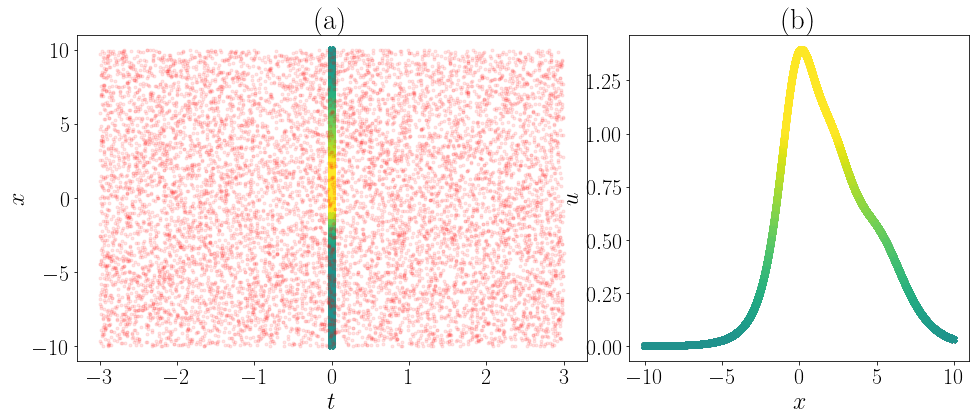

In [9]:
if plot == True:
  fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6),
                                 gridspec_kw={
                                     'width_ratios': [9, 6],
                                     'wspace': 0.1})
  
  ax1.scatter(t_0, x_0, c=u_0, marker='X', vmin=-1, vmax=1)
  ax1.scatter(t_r, x_r, c='r', marker='.', alpha=0.1)
  ax1.set_xlabel('$t$')
  ax1.set_ylabel('$x$')
  ax1.set_title('(a)')

  ax2.scatter(x_0, u_0, c=u_0, marker='X', vmin=-1, vmax=1)
  ax2.set_xlabel('$x$')
  ax2.set_ylabel('$u$')
  # ax2.invert_yaxis()
  ax2.set_title('(b)')

  # plt.savefig('kdv_eqn_fwd_train.pdf', dpi=600, bbox_inches='tight', facecolor='none')
  plt.show()

### Persiapan Perhitungan *Loss Function*

In the following code cell, we define a function which evaluates the residual

$$
\begin{align}
    r_\theta (t,x) := \partial_t u_\theta (t,x) + \mathcal{N}[u_\theta] (t,x).
\end{align}
$$

of the nonlinear PDE in the points $X_r = \{(t^r_i,x^r_i)\}_{i=1}^{N_r}$.
To compute the necessary partial derivatives we use the automatic differentiation capabilities of TensorFlow.

For the kdv equation, this entails computing $\partial_t u_\theta$, $\partial_x u_\theta$ and $\partial_{xx} u_\theta$.
In TensorFlow, this is done via a `GradientTape`, see also the [documentation](https://www.tensorflow.org/api_docs/python/tf/GradientTape), which keeps track of the `watched` variables, in our case `t` and `x`, in order to compute the derivatives.

In [10]:
def get_r(t, x, model, fun_r):
    
    # A tf.GradientTape is used to compute derivatives in TensorFlow
    with tf.GradientTape(persistent=True) as tape1:  
        
        tape1.watch(x)        
        with tf.GradientTape(persistent=True) as tape2:
          
          tape2.watch(x)
          with tf.GradientTape(persistent=True) as tape3:
          
            # Variables t and x are watched during tape
            # to compute derivatives u_t and u_x
            tape3.watch(t)
            tape3.watch(x)
          
            # Determine residual 
            u = model(tf.stack([t[:,0], x[:,0]], axis=1))

          # Compute gradient u_x and u_t
          u_t = tape3.gradient(u, t)
          u_x = tape3.gradient(u, x)       
        
        u_xx = tape2.gradient(u_x, x)
    
    u_xxx = tape1.gradient(u_xx, x)

    del tape1
    del tape2
    del tape3

    return fun_r(t, x, u, u_t, u_x, u_xx, u_xxx)


# # Alternative with tf.gradients
# def fwd_gradients(U, x):
#   return tf.gradients(U, x)[0]

# @tf.function  
# def get_r(t, x, model, fun_r):
#   u = model(tf.stack([t[:,0], x[:,0]], axis=1))
#   u_t = fwd_gradients(u, t)
#   u_x = fwd_gradients(u, x)
#   u_xx = fwd_gradients(u_x, x)
#   u_xxx = fwd_gradients(u_xx, x)

#   return fun_r(t, x, u, u_t, u_x, u_xx, u_xxx)

### Persiapan Arsitektur PINN

In this example, adopted from 
([Raissi et al., 2017 (Part I)](https://arxiv.org/abs/1711.10561)), we assume a feedforward neural network of the following structure:
- the input is scaled elementwise to lie in the interval $[-1,1]$,
- followed by 8 fully connected layers each containing 20 neurons and each followed by a hyperbolic tangent activation function,
- one fully connected output layer.

Pada *hidden layer* pertama, terdapat $2 \times 20 = 40$ parameter bobot dan $20$ parameter bias. Pada 9 *hidden layer* selanjutnya, terdapat $20 \times 20 = 400$ parameter bobot dan $20$ parameter bias dalam setiap *layer*. Di *output layer* yang terhubung *hidden layer* terakhir, terdapat $1 \times 20 = 20$ parameter bobot dan $20$ parameter bias. 

Maka, terdapat sejumlah
    \begin{align*}
        1 \times (40+20) + 9 \times (400+20) + 1 \times (20+20) = 3880
    \end{align*}
    parameter yang dapat ditentukan dan diperbarui pada setiap *epoch* dalam PINN.

In [11]:
# Initialize model aka u_\theta
arch = {'output_dim':1, 'num_hidden_layers':10, 'num_neurons_per_layer':20, 'activation':'tanh'}
n_models = 5

In [12]:
# Set up model architecture & 
# initialize weights to be copied to other models

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = pinn.PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 2))

## 2. Persiapan *Optimizer*

In [13]:
# Preparing learning rates
lr_exp = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=450,
    decay_rate=0.9)

lr_pw = tf.keras.optimizers.schedules.PiecewiseConstantDecay([10000,20000],[1e-3,1e-4,5e-5])

lr_comb = CombinedDecay(boundaries=[1000,3000],
                        initial_learning_rate=1e-3,
                        decay_steps=450,
                        decay_rate=0.9,
                        values_steps=[4,20])

lr_comb.get_config()

{'initial_learning_rate': 0.001,
 'decay_steps': 450,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [1000, 3000],
 'values': [0.000791255401315759,
  0.00019781385032893975,
  9.890692516446987e-06],
 'values_steps': [4, 20],
 'name': None}

# Pemodelan

### Model

In [ ]:
mod=pinn.PINN_NeuralNet(lb, ub, **arch)
mod.build(input_shape=(None,2))
mod.set_weights(models[0].get_weights())

solver = pinn.PINN_PDESolver(mod, X_r, fun_r, get_r)
t0 = time()

# L-BFGS
solver.solve_with_ScipyOptimizer(X_data, u_data,min_loss=1e-5,
                            method='L-BFGS-B',
                            options={'maxiter': 50000,
                                     'maxfun': 50000,
                                     'maxcor': 50,
                                     'maxls': 50,
                                     'ftol': 1.0*np.finfo(float).eps})

# Adam
# optim = tf.keras.optimizers.Adam(learning_rate=lr_exp)
# solver.solve_with_TFoptimizer(optim, X_data, u_data, min_loss=1e-5)

print('\nComputation time: {} seconds'.format(time()-t0))

It 00000: l_u = 2.15297453e-01 l_f = 2.80193286e-03 loss = 2.18099385e-01
It 00050: l_u = 3.87814641e-03 l_f = 1.10631017e-02 loss = 1.49412481e-02
It 00100: l_u = 1.16193108e-03 l_f = 4.45879437e-03 loss = 5.62072545e-03
It 00150: l_u = 6.90479996e-04 l_f = 2.84015457e-03 loss = 3.53063457e-03
It 00200: l_u = 5.61496941e-04 l_f = 2.01491755e-03 loss = 2.57641450e-03
It 00250: l_u = 5.13368635e-04 l_f = 1.46179914e-03 loss = 1.97516778e-03
It 00300: l_u = 4.20337310e-04 l_f = 1.09326129e-03 loss = 1.51359860e-03
It 00350: l_u = 4.67590464e-04 l_f = 7.87375669e-04 loss = 1.25496613e-03
It 00400: l_u = 4.72508196e-04 l_f = 6.47975306e-04 loss = 1.12048350e-03
It 00450: l_u = 4.12135618e-04 l_f = 5.85801783e-04 loss = 9.97937401e-04
It 00500: l_u = 3.67103901e-04 l_f = 5.67877840e-04 loss = 9.34981741e-04
It 00550: l_u = 3.42650397e-04 l_f = 5.13089064e-04 loss = 8.55739461e-04
It 00600: l_u = 2.87676405e-04 l_f = 5.20847272e-04 loss = 8.08523677e-04
It 00650: l_u = 2.72778561e-04 l_f = 4

<AxesSubplot:xlabel='$n_{epoch}$', ylabel='$\\phi^{n_{epoch}}$'>

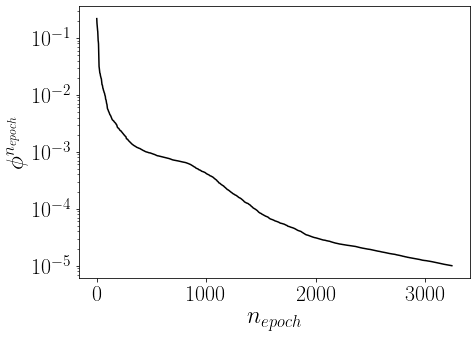

In [ ]:
solver.plot_loss_history()

### *Export* Model

*Export* bobot dan bias yang diperoleh pada *training*. *Export* riwayat *loss* pada *training* dalam bentuk `hist`.

In [ ]:
path = dir + "/model weights/kdv_3sol"
mod.save_weights(path+"/mod.h5", 'h5')
np.savetxt(path+"/loss.txt", solver.hist)

### *Import* Model
*Import* model beserta *loss* dari 5 percobaan pemodelan yang telah dilakukan. Langkah ini diperlukan jika penggunaan model di luar *training runtime*.

In [14]:
# timeout = 100
path = dir + "/model weights/kdv_3sol"

arch = {'output_dim':1, 'num_hidden_layers':10, 'num_neurons_per_layer':20, 'activation':'tanh'}

mod = pinn.PINN_NeuralNet(lb, ub, **arch)
mod.build(input_shape=(None,2))
mod.load_weights(path+"/mod.h5")
hist = np.loadtxt(path+"/loss.txt")

solver = pinn.PINN_PDESolver(mod, X_r, fun_r, get_r)

## Prediksi Solusi dan Evaluasi Kinerja Model

In [15]:
Nt = 1000; Nx = 1000
tspace = np.linspace(lb[0], ub[0], Nt + 1)
xspace = np.linspace(lb[1], ub[1], Nx + 1)
T, X = np.meshgrid(tspace, xspace)

### Solusi Eksplisit

In [16]:
path = dir + "/Data/"

# # Solusi Eksplisit
# u_star = np.empty([len(xspace), len(tspace)])
# i = 0
# for x_i in xspace:
#   j = 0
#   for t_i in tspace:    
#     u_star[i][j] = u_expl(t_i, x_i); j += 1
#   i += 1

# Solusi Eksplisit [[0, 300], [300, 600], [600, 1001]]
# u_star = np.empty([len(xspace), len(tspace)])
# for i in range(600, 1001):
#   j = 0
#   for t_i in tspace:    
#     u_star[i][j] = u_expl(t_i, xspace[i]); j += 1
#   i += 1

# u_star1 = np.loadtxt(path + "u_star_kdv_3soliton_1.csv")
# u_star2 = np.loadtxt(path + "u_star_kdv_3soliton_2.csv")
# u_star3 = np.loadtxt(path + "u_star_kdv_3soliton_3.csv")
# u_star = np.concatenate((u_star1[0:300], u_star2[300:600], u_star3[600:1001]), axis = 0)
# del u_star1, u_star2, u_star3

# np.savetxt(path + "u_star_kdv_3soliton.csv", u_star)

u_star = np.loadtxt(path + "u_star_kdv_3soliton.csv")

Text(0.5, 0, '$u_(t,x)$')

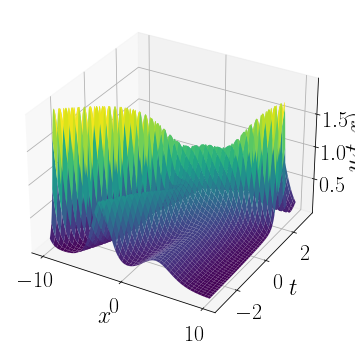

In [17]:
# Surface plot of solution u(t,x)
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, T, u_star, cmap='viridis');
# ax.view_init(35,35)
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_zlabel('$u_(t,x)$')
# ax.set_title('Solusi analitik untuk persamaan panas.');
#plt.savefig('Burgers_Solution.pdf', bbox_inches='tight', dpi=300);

Text(0, 0.5, '$x$')

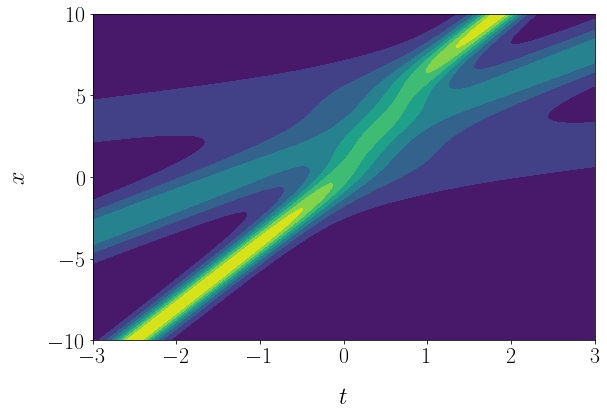

In [18]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111)
ax.contourf(T, X, u_star, cmap='viridis');
ax.set_xlabel('$t$', labelpad=20)
ax.set_ylabel('$x$', labelpad=20)

### Solusi Model

<Axes3D: xlabel='$x$', ylabel='$t$', zlabel='$u_\\theta(t,x)$'>

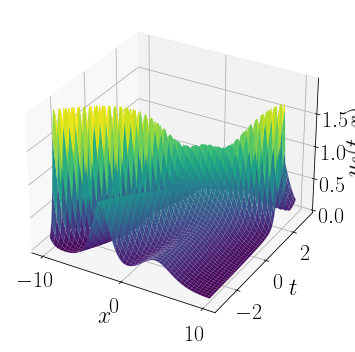

In [19]:
u_PINN = solver.predict_solution()
solver.plot_solution(u_PINN)

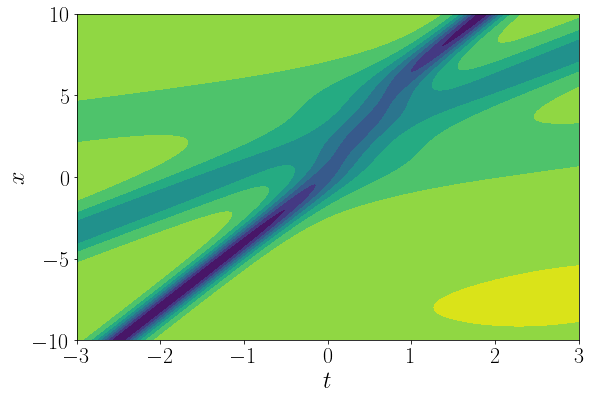

In [20]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111)
ax.contourf(T, X, -u_PINN, cmap='viridis');
ax.set_xlabel('$t$')
ax.set_ylabel('$x$')

plt.savefig('kdv_3soliton_contour.pdf', dpi=600, bbox_inches='tight', facecolor='none')
plt.show()

In [21]:
def tau(t):
  return int((Nt*(t - lb[0])/(ub[0] - lb[0])).numpy())

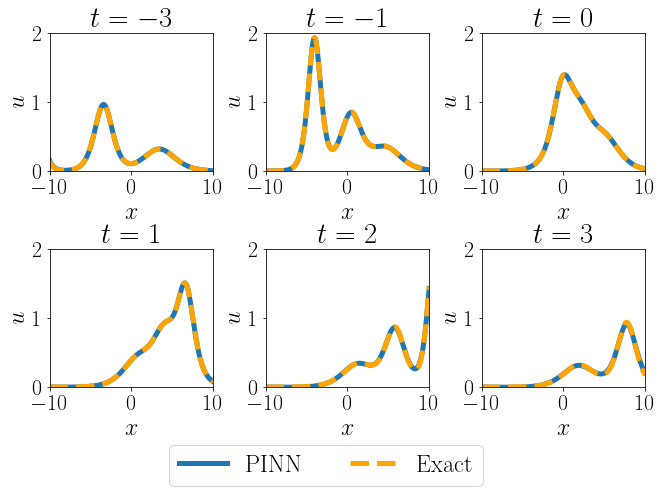

In [22]:
fig, ([ax1, ax2, ax3], [ax4, ax5, ax6]) = plt.subplots(nrows=2, ncols=3, figsize=(9, 6))

time_steps = [-3, -1, 0, 1, 2, 3]

for ax, t in zip([ax1, ax2, ax3, ax4, ax5, ax6], time_steps):
  ax.plot(xspace,u_PINN[:,tau(t)], lw=5)
  ax.plot(xspace,u_star[:,tau(t)], ls="--", lw=5, c='orange')
  ax.set_title('$t={}$'.format(t))
  ax.set_xlabel('$x$')
  ax.set_ylabel('$u$')
  ax.set_xlim([-10,10])
  ax.set_xticks(np.arange(-10, 10+1, 10))
  ax.set_ylim([0,2])

plt.tight_layout(pad=0)
plt.legend(['PINN', 'Exact'], 
           loc='lower center', bbox_to_anchor=(-0.95, -0.8), ncol=2, frameon=True)

plt.savefig('kdv_3soliton_plots.pdf', dpi=600, bbox_inches='tight', facecolor='none')
plt.show()

### Evaluasi Kinerja Model

Prediksi solusi dengan model-model yang telah dibuat.

In [23]:
pinn.evaluate_solution(u_PINN, u_star)

0.853759505417274

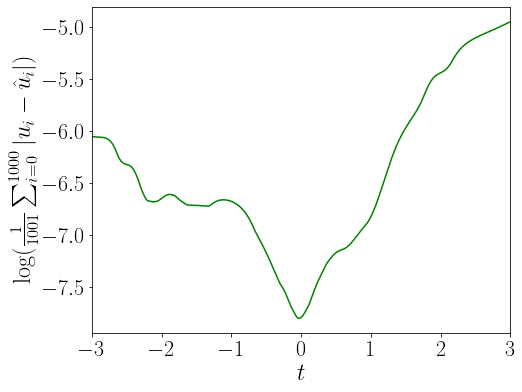

In [24]:
plt.figure(figsize=(7.5, 6))
# f = np.full((len(tspace),),-5.0)

error = pinn.evaluate_solution_log_time(u_PINN, u_star)
plt.plot(tspace, error, c='green')
# plt.plot(tspace, f, '--', c='black')

# idx = np.argwhere(np.diff(np.sign(f - error))).flatten()
# plt.plot(tspace[idx], f[idx], 'ro')

plt.xlabel('$t$')
plt.ylabel('$\log(\\frac{1}{1001}\sum_{i=0}^{1000}{|u_i-\hat{u}_i|})$')
plt.xlim([-3.0,3.0])
plt.xticks(np.arange(-3, 3+1, 1))
# plt.ylim([-9.00,-7.00])

plt.savefig('kdv_3soliton_error.pdf', dpi=600, bbox_inches='tight', facecolor='none')

plt.show()

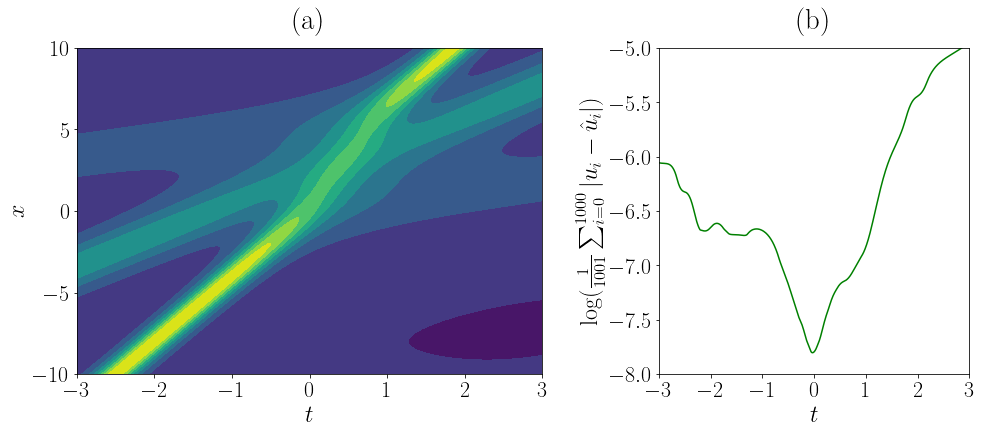

In [25]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6),
                                gridspec_kw={
                                    'width_ratios': [9, 6],
                                    'wspace': 0.3})

ax1.contourf(T, X, u_PINN, cmap='viridis');
ax1.set_xlabel('$t$')
ax1.set_ylabel('$x$')
ax1.set_title('(a)', pad=20)

ax2.plot(tspace, error, c='green')
ax2.set_xlabel('$t$')
ax2.set_ylabel('$\log(\\frac{1}{1001}\sum_{i=0}^{1000}{|u_i-\hat{u}_i|})$')
ax2.set_xlim([-3.0,3.0])
ax2.set_xticks(np.arange(-3, 3+1, 1))
ax2.set_ylim([-8.0,-5.0])
ax2.set_title('(b)', pad=20)

plt.savefig('kdv_3soliton_contour_error.pdf', dpi=600, bbox_inches='tight', facecolor='none')
plt.show()

# Pencarian Parameter Dengan H-PINN

## 1. Persiapan Pemodelan

### Pembangkitan Data *Training* dan *Collocation Points* untuk Masalah Invers

In [ ]:
N_d = 500
noise = 0.0

plot = True

# Set random seed for reproducible results
tf.random.set_seed(0)

if plot == True:  
  # Draw points with measurements randomly
  t_d = tf.random.uniform((N_d,1), lb[0], ub[0], dtype=DTYPE)
  x_d = tf.random.uniform((N_d,1), lb[1], ub[1], dtype=DTYPE)
  X_d = tf.concat([t_d, x_d], axis=1)
  
  tf.keras.backend.set_floatx('float64')
  # Explicit analytical solution
  # vector = np.vectorize(np.float32)
  # u_d = u_expl(vector(t_d.numpy()), vector(x_d.numpy()))
  u_d = u_expl(t_d, x_d)
  u_d += noise * tf.random.normal(u_d.shape, dtype=DTYPE)

  tf.keras.backend.set_floatx(DTYPE)
  tf.cast(u_d, dtype=DTYPE)

elif plot == False:
  X_d, u_d = pinn.generate_collocation_points(N_d, lb, ub, u_expl, noise=0)

X_param = [X_d]
u_param = [u_d]

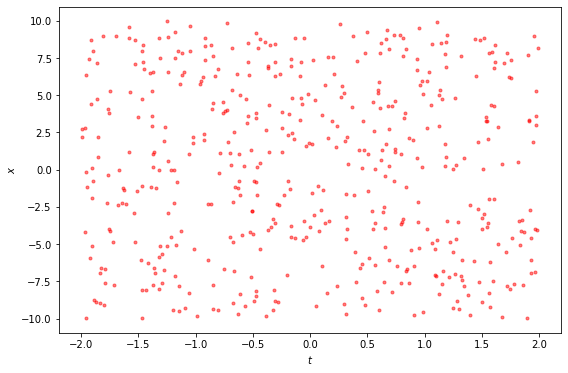

In [ ]:
fig = plt.figure(figsize=(9,6))
plt.scatter(t_d, x_d, c='r', marker='.', alpha=0.5)
plt.xlabel('$t$')
plt.ylabel('$x$')

# plt.title('(b) Visualisasi koordinat data $\it{training}$ dan $\it{collocation\;points}$ untuk masalah invers persamaan KdV.');
# plt.savefig('kdv_eqn_inv_train.pdf', bbox_inches='tight', dpi=600, facecolor='none')

plt.show()

### Persiapan Arsitektur PINN

Pada *hidden layer* pertama, terdapat $2 \times 20 = 40$ parameter bobot dan $20$ parameter bias. Pada *hidden layer* selanjutnya, terdapat $20 \times 20 = 400$ parameter bobot dan $20$ parameter bias dalam setiap *layer*. Di *output layer* yang terhubung *hidden layer* terakhir, terdapat $1 \times 20 = 20$ parameter bobot dan $20$ parameter bias. 

Maka, terdapat sejumlah
    \begin{align*}
        1 \times (40+20) + 1 \times (400+20) + 1 \times (20+20) = 520
    \end{align*}
    parameter yang dapat ditentukan dan diperbarui pada setiap *epoch* dalam PINN.

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':2, 'num_neurons_per_layer':20}
n_models = 5

In [ ]:
models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = pinn.PINN_IdentificationNet(initial_lambda=[0.0, 0.0], lb=lb, ub=ub, **arch)
  models[i].build((None, 2))

### Persiapan Perhitungan *Loss Function*

In [ ]:
def get_r(t, x, model, fun_r):
    
    # A tf.GradientTape is used to compute derivatives in TensorFlow
    with tf.GradientTape(persistent=True) as tape1:  
        
        tape1.watch(x)        
        with tf.GradientTape(persistent=True) as tape2:
          
          tape2.watch(x)
          with tf.GradientTape(persistent=True) as tape3:
          
            # Variables t and x are watched during tape
            # to compute derivatives u_t and u_x
            tape3.watch(t)
            tape3.watch(x)
          
            # Determine residual 
            u = model(tf.stack([t[:,0], x[:,0]], axis=1))

          # Compute gradient u_x and u_t
          u_t = tape3.gradient(u, t)
          u_x = tape3.gradient(u, x)       
        
        u_xx = tape2.gradient(u_x, x)
    
    u_xxx = tape1.gradient(u_xx, x)

    del tape1
    del tape2
    del tape3

    return fun_r(t, x, u, u_t, u_x, u_xx, u_xxx, model)
  
def fun_r(t, x, u, u_t, u_x, u_xx, u_xxx, model):
    return u_t + model.lambd[0] * u * u_x + model.lambd[1] * u_xxx

In [ ]:
def get_r_param(t, x, model):
    
    # A tf.GradientTape is used to compute derivatives in TensorFlow
    with tf.GradientTape(persistent=True) as tape:
        # Split t and x to compute partial derivatives
        # t, x = X_r[:, 0:1], X_r[:,1:2]
        
        tape.watch(x)
        with tf.GradientTape(persistent=True) as tape2:
          
          tape2.watch(x)
          with tf.GradientTape(persistent=True) as tape3:
            tape3.watch(t)
            tape3.watch(x)

            # Determine residual 
            u = model(tf.stack([t[:,0], x[:,0]], axis=1))
          
          u_t = tape3.gradient(u, t)
          u_x = tape3.gradient(u, x)

        # Compute gradient u_x within the GradientTape
        # since we need second derivatives        
        u_xx = tape2.gradient(u_x, x)
            
    
    u_xxx = tape.gradient(u_xx, x)

    del tape
    del tape2
    del tape3

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      r = u_t + model.lambd[0] * u * u_x + model.lambd[1] * u_xxx
      loss = tf.reduce_mean(tf.square(r))
    
    g = tape_lambd.gradient(loss, model.lambd)
    
    del tape_lambd    

    return loss, g

## 2. Persiapan *Optimizer*

Karena data yang digunakan lebih sedikit untuk kasus masalah invers, maka iterasi *optimizer* berbasis *gradient descent* akan menjadi lebih banyak. Maka, boundary untuk *learning rate* yang akan digunakan pada *Piecewise Constant Decay* harus lebih besar.

In [ ]:
# lr_pw = tf.keras.optimizers.schedules.PiecewiseConstantDecay([3000,7000],[1e-1,1e-2,1e-3])

# # Choose the optimizer
# optim_SGD = tf.keras.optimizers.SGD(learning_rate=lr_pw)
# optim_Adam = tf.keras.optimizers.Adam(learning_rate=lr_pw)

# boundaries = [3000,7000]
# values = [1e-1,1e-2,1e-3]
lr_comb_param = {'boundaries': [3000,7000,14000],
                 'initial_learning_rate': 1e-1,
                 'decay_steps': 150,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecay(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.1,
 'decay_steps': 150,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [3000, 7000, 14000],
 'values': [0.012157665459056936,
  0.006078832729528468,
  0.003039416364764234,
  0.001519708182382117],
 'values_steps': [2, 2, 2],
 'name': None}

## 3. *Training* Model

In [ ]:
n_models = 1
timeout = 100
initial_lambdas = [[0.0, 0.0], [1.0, -6.0], [10.0, 10.0]]
path = dir + "/model weights/kdv_eqn_inv"

old_timeout = timeout
models_LBFGS = [None] * n_models
models_SGD = [None] * n_models
models_Adam = [None] * n_models
hists_LBFGS = [None] * n_models
hists_SGD = [None] * n_models
hists_Adam = [None] * n_models


for i in range(n_models):
  timeout = old_timeout
  models_LBFGS[i] = []
  models_SGD[i] = []
  models_Adam[i] = []
  hists_LBFGS[i] = []
  hists_SGD[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    models_LBFGS[i].append(pinn.PINN_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))
    models_SGD[i].append(pinn.PINN_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))
    models_Adam[i].append(pinn.PINN_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch)) 
    
    models_LBFGS[i][j].build((None, 2))
    models_SGD[i][j].build((None, 2))
    models_Adam[i][j].build((None, 2))

    # Copy weights from the previous model instance to make every iteration comparable
    models_LBFGS[i][j].set_weights(models[i].get_weights())
    models_SGD[i][j].set_weights(models[i].get_weights())
    models_Adam[i][j].set_weights(models[i].get_weights())
    
    # Assigning initial lambda
    models_LBFGS[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_SGD[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])

    # Prepare optimizer
    optim_SGD = tf.keras.optimizers.SGD(learning_rate=lr_comb)
    optim_Adam = tf.keras.optimizers.Adam(learning_rate=lr_comb)

    # Initialize solver
    # solver_LBFGS = pinn.PINN_IdentificationSolver(models_LBFGS[i][j], X_d, fun_r, get_r)
    # solver_SGD = pinn.PINN_IdentificationSolver(models_SGD[i][j], X_d, fun_r, get_r)
    solver_Adam = pinn.PINN_IdentificationSolver(models_Adam[i][j], X_d, fun_r, get_r)

    # Train models
    print('\n\nL-BFGS\n')
    # solver_LBFGS.solve_with_ScipyOptimizer(X_param, u_param,
    #                                       timeout=timeout,
    #                                       method='L-BFGS-B')
    # print('\n\nSGD\n')
    # solver_SGD.solve_with_TFoptimizer(optim_SGD, X_param, u_param, timeout=timeout)
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, X_param, u_param, timeout=timeout)
    
    # Store evolution of lambdas and hists
    # hists_LBFGS[i].append(np.array([models_LBFGS[i][j].lambd_list, solver_LBFGS.hist]))
    # hists_SGD[i].append(np.array([models_SGD[i][j].lambd_list, solver_SGD.hist]))
    hists_Adam[i].append(np.array([models_Adam[i][j].lambd_list, solver_Adam.hist]))

    # hists_LBFGS[i][j] = np.column_stack((np.stack(hists_LBFGS[i][j][0], axis=0), hists_LBFGS[i][j][1]))
    # hists_SGD[i][j] = np.column_stack((np.stack(hists_SGD[i][j][0], axis=0), hists_SGD[i][j][1]))
    hists_Adam[i][j] = np.column_stack((np.stack(hists_Adam[i][j][0], axis=0), hists_Adam[i][j][1]))

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: [0.0, 0.0]
--------------------------------------------------


L-BFGS



Adam

It 00000: loss = 4.50128478e-01 lambda = [ 0.08749208 -0.08970757]
It 00050: loss = 1.29281979e-01 lambda = [0.0474399  0.38655559]
It 00100: loss = 7.57290075e-02 lambda = [ 4.09816147 -3.75445353]
It 00150: loss = 6.82669170e-02 lambda = [ 4.75526625 -1.22002799]
It 00200: loss = 3.60476027e-02 lambda = [6.53687022 1.18041186]
It 00250: loss = 3.21049367e-02 lambda = [6.04046191 0.86816194]
It 00300: loss = 2.96704989e-02 lambda = [5.78233591 0.84555794]
It 00350: loss = 3.33934866e-02 lambda = [5.67040557 0.66506366]
It 00400: loss = 2.96958909e-02 lambda = [5.90788246 0.67948395]
It 00450: loss = 4.76743756e-02 lambda = [5.80583146 0.55916874]
It 00500: loss = 1.55484297e-02 lambda = [5.98181    0.86131264]
It 00550: loss = 1.50342496e-02 lambda = [5.9235141  0.91669319]
It 00600: loss = 4.76123490e-02 lambda = [5.45195985 0

<ipython-input-15-a6bdd767d43a>:67: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  hists_Adam[i].append(np.array([models_Adam[i][j].lambd_list, solver_Adam.hist]))






--------------------------------------------------
Iteration: 1 Initial lambda: [1.0, -6.0]
--------------------------------------------------


L-BFGS



Adam

It 00000: loss = 4.49949378e-01 lambda = [ 1.07038025 -6.08958322]
It 00050: loss = 1.26887610e-01 lambda = [ 0.69577568 -4.02330171]
It 00100: loss = 7.41737488e-02 lambda = [ 3.74359086 -6.11267521]
It 00150: loss = 6.02826608e-02 lambda = [ 4.84530336 -1.62980006]
It 00200: loss = 4.17087526e-02 lambda = [6.20741243 1.13731647]
It 00250: loss = 2.86888826e-02 lambda = [6.1650452  0.96208437]
It 00300: loss = 2.54288806e-02 lambda = [6.02125998 1.07513403]
It 00350: loss = 2.33823585e-02 lambda = [6.00073509 0.95620414]
It 00400: loss = 1.60797554e-02 lambda = [6.05258343 0.99491699]
It 00450: loss = 1.37633165e-02 lambda = [6.03917938 1.02927606]
It 00500: loss = 3.49069570e-02 lambda = [6.05471829 0.99626251]
It 00550: loss = 1.07211814e-02 lambda = [6.06105337 1.03536694]
It 00600: loss = 1.28820068e-02 lambda = [6.028

### *Export* Model

*Export* bobot dan bias yang diperoleh pada *training*.

In [ ]:
path = dir + "/model weights/kdv_eqn_inv"

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_LBFGS[i][j].save_weights(path+"_"+str(i)+"/model_LBFGS_"+str(j)+".h5", 'h5')
    models_SGD[i][j].save_weights(path+"_"+str(i)+"/model_SGD_"+str(j)+".h5", 'h5')
    models_Adam[i][j].save_weights(path+"_"+str(i)+"/model_Adam_"+str(j)+".h5", 'h5')

*Export* perkembangan *loss* pada *training* dalam bentuk `hist`.

In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path+"_"+str(i)+"/loss and param/hist_LBFGS_"+str(j)+".txt", hists_LBFGS[i][j])
    np.savetxt(path+"_"+str(i)+"/loss and param/hist_SGD_"+str(j)+".txt", hists_SGD[i][j])
    np.savetxt(path+"_"+str(i)+"/loss and param/hist_Adam_"+str(j)+".txt", hists_Adam[i][j])

### *Import* Model

In [ ]:
n_models = 5
timeout = 100
initial_lambdas = [[0.0, 0.0], [1.0, -6.0], [10.0, 10.0]]
path = dir + "/model weights/kdv_eqn_inv"

models_LBFGS = [None] * n_models
models_SGD = [None] * n_models
models_Adam = [None] * n_models
hists_LBFGS = [None] * n_models
hists_SGD = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  models_LBFGS[i] = []
  models_SGD[i] = []
  models_Adam[i] = []
  hists_LBFGS[i] = []
  hists_SGD[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    models_LBFGS[i].append(pinn.PINN_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))
    models_SGD[i].append(pinn.PINN_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))
    models_Adam[i].append(pinn.PINN_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch)) 
    
    models_LBFGS[i][j].build((None, 2))
    models_SGD[i][j].build((None, 2))
    models_Adam[i][j].build((None, 2))

    models_LBFGS[i][j].load_weights(path+"_"+str(i)+"/model_LBFGS_"+str(j)+".h5", 'h5')
    models_SGD[i][j].load_weights(path+"_"+str(i)+"/model_SGD_"+str(j)+".h5", 'h5')
    models_Adam[i][j].load_weights(path+"_"+str(i)+"/model_Adam_"+str(j)+".h5", 'h5')

    hists_LBFGS[i].append(np.loadtxt(path+"_"+str(i)+"/loss and param/hist_LBFGS_"+str(j)+".txt"))
    hists_SGD[i].append(np.loadtxt(path+"_"+str(i)+"/loss and param/hist_SGD_"+str(j)+".txt"))
    hists_Adam[i].append(np.loadtxt(path+"_"+str(i)+"/loss and param/hist_Adam_"+str(j)+".txt"))

## Analisis Hasil Prediksi

In [ ]:
def lambdas(hists, iter_model, iter_init, lambd_init, N=500):
  return sum(hists[iter_model][iter_init][-N:,lambd_init]) / N

cols = ['L-BFGS_0', 'L-BFGS_1',
        'SGD_0', 'SGD_1', 
        'Adam_0', 'Adam_1']
df1 = pd.DataFrame(columns = cols)
df2 = pd.DataFrame(columns = cols)
df3 = pd.DataFrame(columns = cols)

for i in range(n_models):
  x = []
  x.append(lambdas(hists_LBFGS, i, 0, 0)); x.append(lambdas(hists_LBFGS, i, 0, 1))
  x.append(lambdas(hists_SGD, i, 0, 0)); x.append(lambdas(hists_SGD, i, 0, 1))
  x.append(lambdas(hists_Adam, i, 0, 0)); x.append(lambdas(hists_Adam, i, 0, 1))
  df1.loc['Attempt '+str(i+1)] = x

df1.loc['Average'] = df1.mean(axis=0)

for i in range(n_models):
  x = []
  x.append(lambdas(hists_LBFGS, i, 1, 0)); x.append(lambdas(hists_LBFGS, i, 1, 1))
  x.append(lambdas(hists_SGD, i, 1, 0)); x.append(lambdas(hists_SGD, i, 1, 1))
  x.append(lambdas(hists_Adam, i, 1, 0)); x.append(lambdas(hists_Adam, i, 1, 1))
  df2.loc['Attempt '+str(i+1)] = x

df2.loc['Average'] = df2.mean(axis=0)

for i in range(n_models):
  x = []
  x.append(lambdas(hists_LBFGS, i, 2, 0)); x.append(lambdas(hists_LBFGS, i, 2, 1))
  x.append(lambdas(hists_SGD, i, 2, 0)); x.append(lambdas(hists_SGD, i, 2, 1))
  x.append(lambdas(hists_Adam, i, 2, 0)); x.append(lambdas(hists_Adam, i, 2, 1))
  df3.loc['Attempt '+str(i+1)] = x

df3.loc['Average'] = df3.mean(axis=0)

In [ ]:
print(tabulate(df1.round(4), headers='keys', tablefmt='latex', floatfmt="#.4f"))
print(tabulate(df2.round(4), headers='keys', tablefmt='latex', floatfmt="#.4f"))
print(tabulate(df3.round(4), headers='keys', tablefmt='latex', floatfmt="#.4f"))

\begin{tabular}{lrrrrrr}
\hline
           &   L-BFGS\_0 &   L-BFGS\_1 &   SGD\_0 &   SGD\_1 &   Adam\_0 &   Adam\_1 \\
\hline
 Attempt 1 &    -5.9888 &     0.9962 & -0.8925 & -0.5300 &  -6.0000 &   1.0000 \\
 Attempt 2 &    -5.9940 &     0.9976 & -0.8844 & -0.5951 &  -5.9998 &   1.0000 \\
 Attempt 3 &    -6.0031 &     1.0013 & -1.2734 & -0.8983 &  -6.0006 &   1.0002 \\
 Attempt 4 &    -6.0053 &     1.0022 & -1.4010 & -0.9241 &  -6.0000 &   1.0000 \\
 Attempt 5 &    -6.0674 &     1.0259 & -1.3908 & -0.9049 &  -6.0001 &   1.0000 \\
 Average   &    -6.0117 &     1.0046 & -1.1684 & -0.7705 &  -6.0001 &   1.0000 \\
\hline
\end{tabular}
\begin{tabular}{lrrrrrr}
\hline
           &   L-BFGS\_0 &   L-BFGS\_1 &   SGD\_0 &   SGD\_1 &   Adam\_0 &   Adam\_1 \\
\hline
 Attempt 1 &    -3.8661 &    -0.7705 &  0.5554 & -6.0954 &  -5.9995 &   0.9998 \\
 Attempt 2 &    -3.8347 &    -0.8067 &  0.5511 & -6.0340 &  -5.9997 &   0.9999 \\
 Attempt 3 &    -3.7654 &    -0.8907 &  0.4996 & -6.0623 &  -5.9965 &

## *Training* Model *Hybrid*

In [ ]:
n_models = 1
timeout = 100
initial_lambdas = [[0.0, 0.0], [1.0, -6.0], [10.0, 10.0]]
initial_lambdas = [[1.0, -6.0], [10.0, 10.0]]
path = dir + "/model weights/kdv_eqn_inv"

old_timeout = timeout
models = [None] * n_models
models_Adam = [None] * n_models
hists_Adam = [None] * n_models
hists_Adam = [None] * n_models
lambds_Adam = [None] * n_models
losses_Adam = [None] * n_models


for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = pinn.Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 2))

  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []
  lambds_Adam[i] = []
  losses_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    models_Adam[i].append(pinn.Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch)) 
    models_Adam[i][j].build((None, 2))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())
    
    # Assigning initial lambda
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer for learning given data
    optim_Adam = tf.keras.optimizers.Adam(learning_rate=lr_comb)    

    # Prepare optimizer for minimizing PDE function and finding PDE parameters
    optim_inv_Adam = tf.keras.optimizers.Adam(learning_rate=lr_comb)

    # Initialize solver
    solver_hybrid = pinn.Hybrid_IdentificationSolver(models_Adam[i][j], X_d, fun_r, get_r)

    # Train models
    print('\n\nAdam\n')
    solver_hybrid.solve(optim_Adam, optim_inv_Adam, get_r_param, X_param, u_param, 
                        timeout_param=timeout*0.8, timeout=timeout*0.2)
    
    # Store evolution of lambdas and hists
    hists_Adam[i].append(np.array([models_Adam[i][j].lambd_list, solver_hybrid.hist]))
    lambds_Adam[i].append(np.stack(hists_Adam[i][j][0], axis=0))
    losses_Adam[i].append(hists_Adam[i][j][1])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: [1.0, -6.0]
--------------------------------------------------


Adam

It 00000: l_u = 3.68277703e-01 loss = 3.68277703e-01
It 00050: l_u = 5.86921890e-02 loss = 5.86921890e-02
It 00100: l_u = 1.47252923e-02 loss = 1.47252923e-02
It 00150: l_u = 6.27197516e-03 loss = 6.27197516e-03
It 00200: l_u = 4.39104358e-03 loss = 4.39104358e-03
It 00250: l_u = 3.73544424e-03 loss = 3.73544424e-03
It 00300: l_u = 3.57841879e-03 loss = 3.57841879e-03
It 00350: l_u = 2.95758109e-03 loss = 2.95758109e-03
It 00400: l_u = 2.72439035e-03 loss = 2.72439035e-03
It 00450: l_u = 2.54872681e-03 loss = 2.54872681e-03
It 00500: l_u = 2.39436230e-03 loss = 2.39436230e-03
It 00550: l_u = 2.24023084e-03 loss = 2.24023084e-03
It 00600: l_u = 2.06653192e-03 loss = 2.06653192e-03
It 00650: l_u = 1.85557028e-03 loss = 1.85557028e-03
It 00700: l_u = 1.91835640e-03 loss = 1.91835640e-03
It 00750: l_u = 1.38532134e-03 loss = 1.38532134e-03
I

AttributeError: ignored

In [ ]:
def lambdas(hists, iter_model, iter_init, lambd_init, N=500):
  return sum(hists[iter_model][iter_init][-N:,lambd_init]) / N

df = pd.DataFrame(columns = ['Adam_0_1','Adam_0_2',
                             'Adam_1_1','Adam_1_2',
                             'Adam_2_1','Adam_2_2'])

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(lambds_Adam, i, j, 0))
    x.append(lambdas(lambds_Adam, i, j, 1))
  
  df.loc['Attempt '+str(i+1)] = x

df

,Adam_0_1,Adam_0_2,Adam_1_1,Adam_1_2,Adam_2_1,Adam_2_2
Attempt 1,-5.937997,0.975401,-5.925421,0.970517,-4.647446,0.585942
Attempt 2,-5.987469,0.993371,-6.012897,0.994178,-4.683389,0.598500
Attempt 3,-5.945903,0.983957,-5.942755,0.984458,-4.714555,0.609711
Attempt 4,-5.896593,0.969936,-5.909860,0.974265,-4.686334,0.600053
Attempt 5,-5.977924,0.991616,-5.974034,0.990323,-4.675133,0.595484


In [ ]:
print(df.mean(axis=0))
df.loc['Average'] = df.mean(axis=0)

Adam_0_1   -5.949177
Adam_0_2    0.982856
Adam_1_1   -5.952993
Adam_1_2    0.982748
Adam_2_1   -4.681372
Adam_2_2    0.597938
dtype: float64


In [ ]:
print(tabulate(df.round(4), headers='keys', tablefmt='latex', floatfmt="#.4f"))

\begin{tabular}{lrrrrrr}
\hline
           &   Adam\_0\_1 &   Adam\_0\_2 &   Adam\_1\_1 &   Adam\_1\_2 &   Adam\_2\_1 &   Adam\_2\_2 \\
\hline
 Attempt 1 &    -5.9380 &     0.9754 &    -5.9254 &     0.9705 &    -4.6474 &     0.5859 \\
 Attempt 2 &    -5.9875 &     0.9934 &    -6.0129 &     0.9942 &    -4.6834 &     0.5985 \\
 Attempt 3 &    -5.9459 &     0.9840 &    -5.9428 &     0.9845 &    -4.7146 &     0.6097 \\
 Attempt 4 &    -5.8966 &     0.9699 &    -5.9099 &     0.9743 &    -4.6863 &     0.6001 \\
 Attempt 5 &    -5.9779 &     0.9916 &    -5.9740 &     0.9903 &    -4.6751 &     0.5955 \\
 Average   &    -5.9492 &     0.9829 &    -5.9530 &     0.9827 &    -4.6814 &     0.5979 \\
\hline
\end{tabular}


### Export Model

In [ ]:
path = dir + "/model weights/kdv_eqn_inv_hybrid"

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"/model_Adam_hy_"+str(i)+"_"+str(j)+".h5", 'h5')

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path+"/loss and param/lambd_Adam_hy_"+str(i)+"_"+str(j)+".txt", lambds_Adam[i][j])
    np.savetxt(path+"/loss and param/loss_Adam_hy_"+str(i)+"_"+str(j)+".txt", losses_Adam[i][j])